In [6]:
# Setup
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Hiragino Sans'
import seaborn as sns
from IPython.display import display

# Load data
df = pd.read_csv('data/supermarket_sales.csv')

# Standardize date and time fields for time-based analysis
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')
df['Hour'] = df['Time'].dt.hour

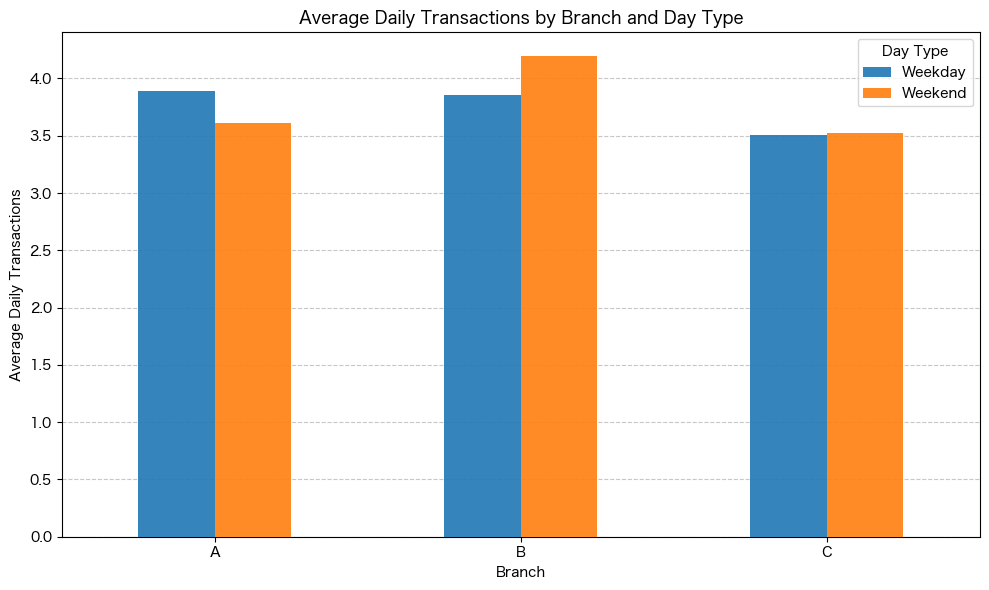

In [7]:
# Step 1 – Compare weekday vs weekend traffic by branch

# Derive weekday and weekend classification
df['Day_name'] = df['Date'].dt.day_name()

def get_day_type(day_name):
    if day_name in ['Saturday', 'Sunday']:
        return 'Weekend'
    return 'Weekday'

df['Day_type'] = df['Day_name'].apply(get_day_type)

# Calculate daily transaction count per branch
daily_traffic = (
    df.groupby(['Date', 'Branch', 'Day_type'])['Invoice ID']
      .nunique()
      .reset_index(name='daily_transactions')
)

# Use average daily transactions to avoid bias from uneven number of days
avg_daily_traffic = (
    daily_traffic.groupby(['Branch', 'Day_type'])['daily_transactions']
                 .mean()
                 .unstack()
)

# Visualization
ax = avg_daily_traffic.plot(kind='bar', figsize=(10, 6), alpha=0.9, zorder=3)

plt.title('Average Daily Transactions by Branch and Day Type')
plt.xlabel('Branch')
plt.ylabel('Average Daily Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

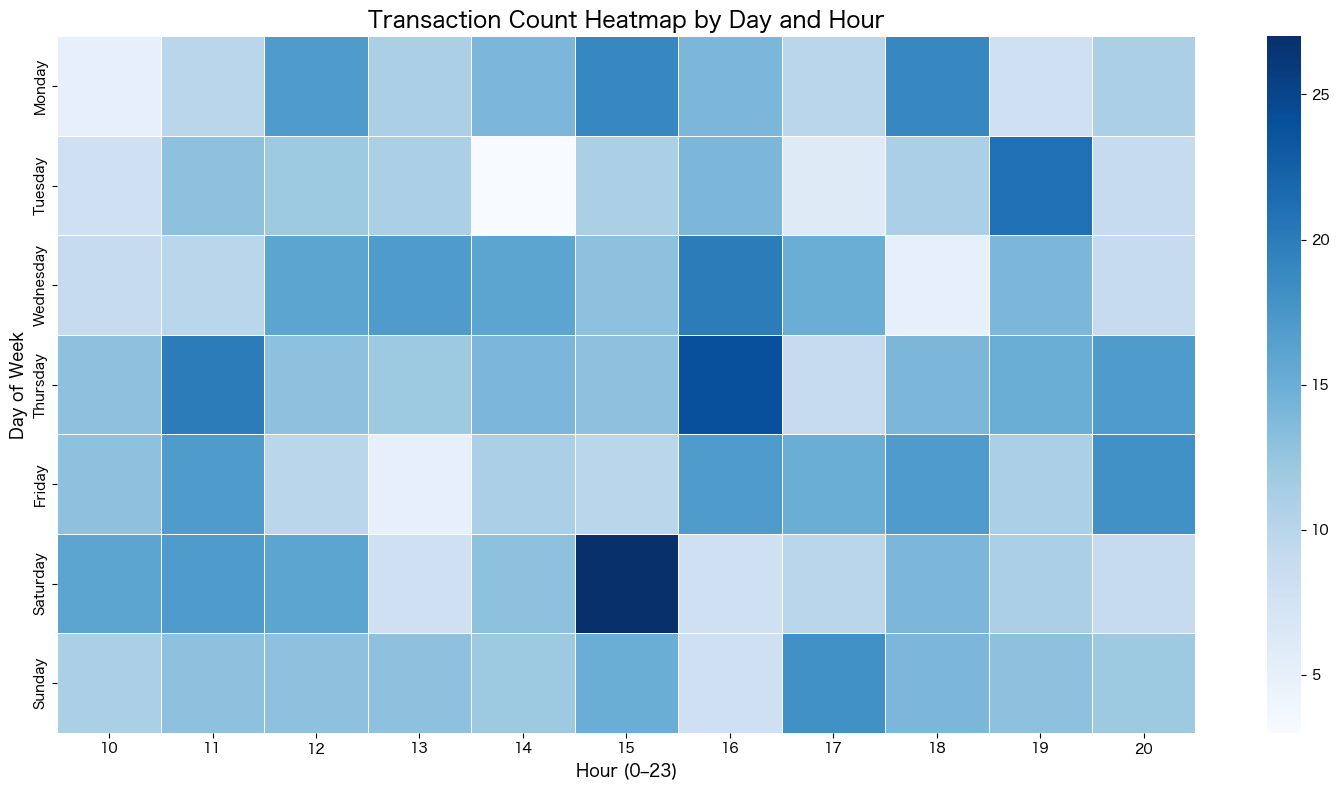

,Day_name,Hour,transaction_count,time_window
60,Saturday,15,27,15:00–15:59
39,Thursday,16,24,16:00–16:59
20,Tuesday,19,21,19:00–19:59
34,Thursday,11,20,11:00–11:59
28,Wednesday,16,20,16:00–16:59
5,Monday,15,19,15:00–15:59
8,Monday,18,19,18:00–18:59
73,Sunday,17,18,17:00–17:59
54,Friday,20,18,20:00–20:59
56,Saturday,11,17,11:00–11:59


In [8]:
# Step 2 – Identify the busiest time slot (day_name × hour)

# Metric: transaction count (unique Invoice ID)
traffic_by_day_hour = pd.pivot_table(
    df,
    values = 'Invoice ID',
    index = 'Day_name',
    columns = 'Hour',
    aggfunc=pd.Series.nunique
)

# Ensure weekday order for readability
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traffic_by_day_hour = traffic_by_day_hour.reindex(days_order)

# Visualization (heatmap is for intuition; Top-N below is the evidence)
plt.figure(figsize=(15, 8))
sns.heatmap(
    data = traffic_by_day_hour,
    cmap = 'Blues',
    annot = False,
    fmt = '.0f',
    linewidths = 0.5
)
plt.title('Transaction Count Heatmap by Day and Hour', fontsize=16)
plt.xlabel('Hour (0–23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

# Evidence table: Top N busiest slots by traffic
top_n = 10

top_slots = (
    traffic_by_day_hour
    .stack()   # (Day_name, Hour) -> transaction_count
    .reset_index(name='transaction_count')
    .sort_values('transaction_count', ascending=False)
    .head(top_n)
)

def format_time_window(hour):
    return f"{hour:02d}:00–{hour:02d}:59"

top_slots['time_window'] = top_slots['Hour'].apply(format_time_window)
display(top_slots)


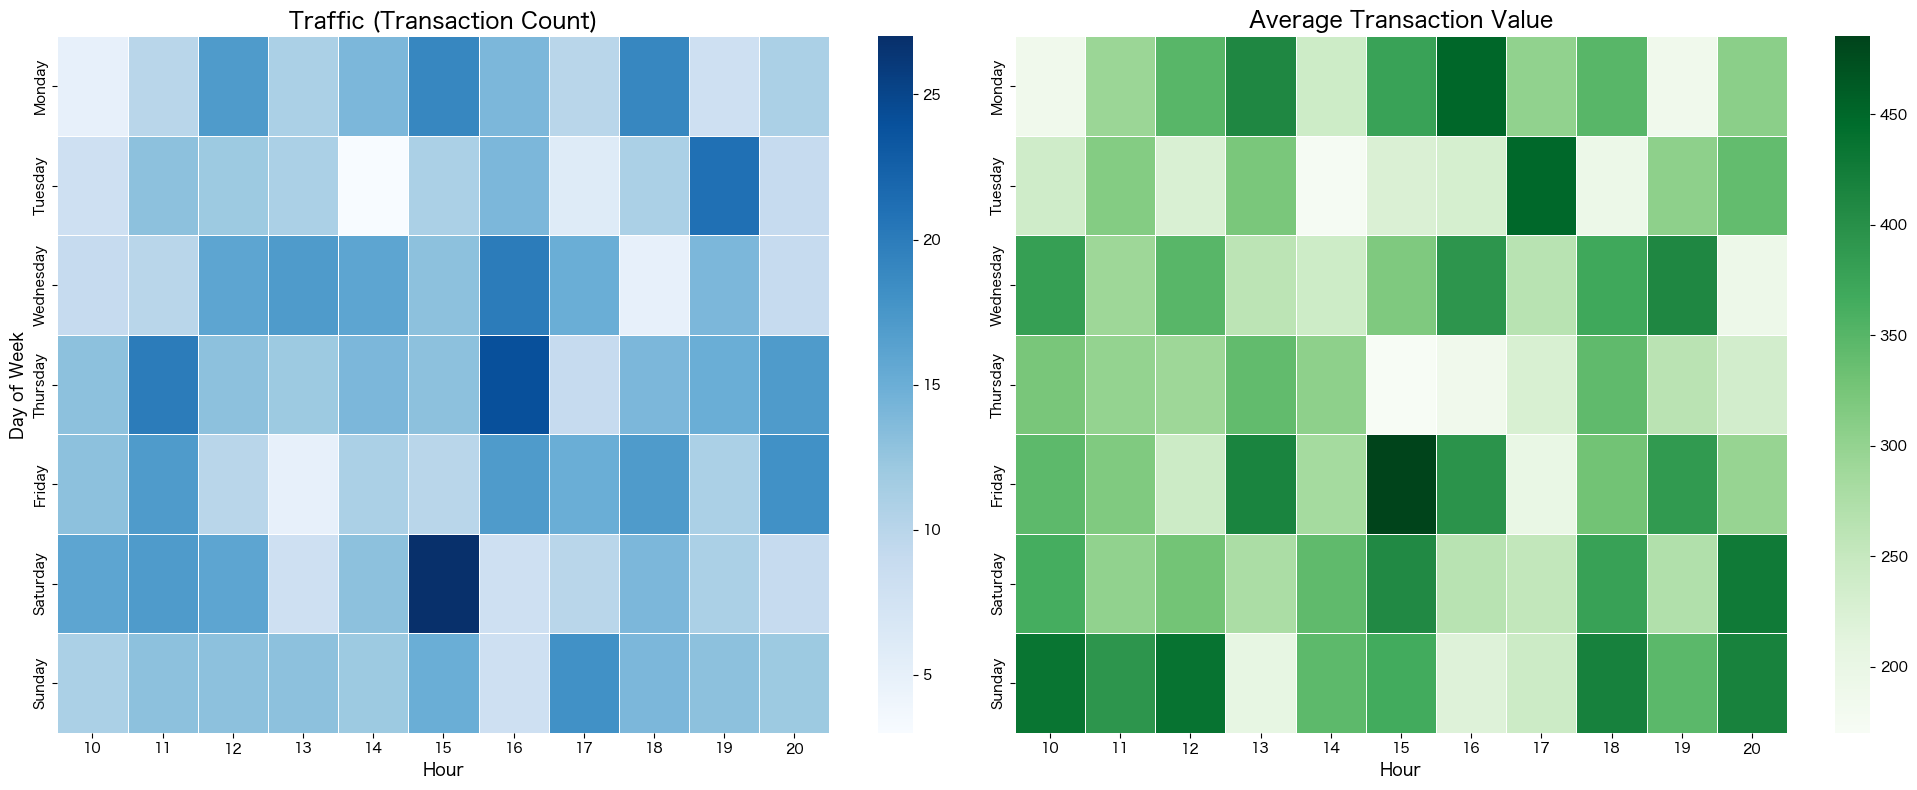

,Metric,Peak Value,Average Value,Ratio (Peak / Average)
0,Traffic,27.000000,12.987013,2.07900
1,ATV,408.618889,312.842198,1.30615


In [9]:
# Step 3 – Explain the peak: traffic-driven vs ATV-driven

# Revenue ≈ Traffic × ATV (decompose the peak slot)
traffic_matrix = pd.pivot_table(
    df,
    values = 'Invoice ID',
    index = 'Day_name',
    columns = 'Hour',
    aggfunc = pd.Series.nunique
)

atv_matrix = pd.pivot_table(
    df,
    values = 'Total',
    index = 'Day_name',
    columns = 'Hour',
    aggfunc = 'mean'
)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traffic_matrix = traffic_matrix.reindex(days_order)
atv_matrix = atv_matrix.reindex(days_order)

# Peak slot identified in Step 2
peak_day = 'Saturday'
peak_hour = 15

# Heatmaps (intuition)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    data = traffic_matrix,
    ax = axes[0],
    cmap = 'Blues',
    annot = False,
    fmt = '.0f',
    linewidths = 0.5
)
axes[0].set_title('Traffic (Transaction Count)', fontsize=16)
axes[0].set_xlabel('Hour', fontsize=12)
axes[0].set_ylabel('Day of Week', fontsize=12)

sns.heatmap(
    data = atv_matrix,
    ax = axes[1],
    cmap = 'Greens',
    annot = False,
    fmt = '.1f',
    linewidths = 0.5
)
axes[1].set_title('Average Transaction Value', fontsize=16)
axes[1].set_xlabel('Hour', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Compare peak slot with overall average to validate the driver

peak_traffic = traffic_matrix.loc[peak_day, peak_hour]
peak_atv = atv_matrix.loc[peak_day, peak_hour]

# Calculate overall average across all day-hour combinations
avg_traffic = traffic_matrix.stack().mean()
avg_atv = atv_matrix.stack().mean()

# Create comparison table
peak_evidence = pd.DataFrame({
    'Metric': ['Traffic', 'ATV'],
    'Peak Value': [peak_traffic, peak_atv],
    'Average Value': [avg_traffic, avg_atv],
    'Ratio (Peak / Average)': [
        peak_traffic / avg_traffic,
        peak_atv / avg_atv
    ]
})

display(peak_evidence)

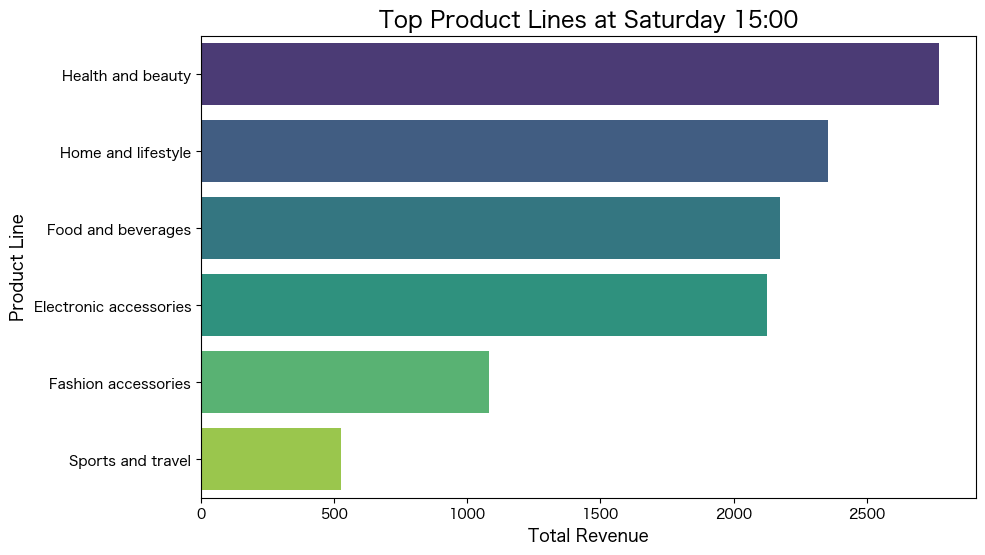

Product line
Health and beauty         45
Home and lifestyle        37
Food and beverages        34
Electronic accessories    27
Fashion accessories       22
Name: Quantity, dtype: int64


In [10]:
# Step 4 – Identify top product lines during the peak hour

# Filter peak slot data
peak_hour_data = df[
    (df['Day_name'] == 'Saturday') & 
    (df['Hour'] == 15)
] 

# Revenue ranking by product line
top_products_revenue = (
    peak_hour_data.groupby('Product line')['Total']
                  .sum()
                  .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x = top_products_revenue.values,
    y = top_products_revenue.index,
    hue = top_products_revenue.index,
    dodge=False,
    legend = False,
    palette = 'viridis'
)

plt.title(f'Top Product Lines at {peak_day} {peak_hour}:00', fontsize=16)
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Line', fontsize=12)
plt.show()

# Supporting view: quantity ranking
top_products_qty = (
    peak_hour_data.groupby('Product line')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
)

print(top_products_qty.head(5))